### Model Selection - Random Forest Classification

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

df['STATISTICAL_MURDER_FLAG'] = df['STATISTICAL_MURDER_FLAG'].astype(int)

X = df.drop('STATISTICAL_MURDER_FLAG', axis=1)
y = df['STATISTICAL_MURDER_FLAG']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})


Accuracy: 0.7658795533589603
              precision    recall  f1-score   support

           0       0.81      0.92      0.86      4431
           1       0.23      0.10      0.14      1032

    accuracy                           0.77      5463
   macro avg       0.52      0.51      0.50      5463
weighted avg       0.70      0.77      0.73      5463



### Model Selection - Decision Tree Classification

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("NYPD_Shooting_Incident_Data__Historic_.csv")

df = df.drop([
    'INCIDENT_KEY',
    'OCCUR_DATE',
    'OCCUR_TIME',
    'X_COORD_CD',
    'Y_COORD_CD',
    'Latitude',
    'Longitude',
    'Lon_Lat'
], axis=1)

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

df['STATISTICAL_MURDER_FLAG'] = df['STATISTICAL_MURDER_FLAG'].astype(int)

X = df.drop('STATISTICAL_MURDER_FLAG', axis=1)
y = df['STATISTICAL_MURDER_FLAG']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})


Accuracy: 0.7532491305143694
              precision    recall  f1-score   support

           0       0.81      0.90      0.86      4431
           1       0.21      0.11      0.15      1032

    accuracy                           0.75      5463
   macro avg       0.51      0.51      0.50      5463
weighted avg       0.70      0.75      0.72      5463



### Model Selection - logistic Regression

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("NYPD_Shooting_Incident_Data__Historic_.csv")

df = df.drop([
    'INCIDENT_KEY',
    'OCCUR_DATE',
    'OCCUR_TIME',
    'X_COORD_CD',
    'Y_COORD_CD',
    'Latitude',
    'Longitude',
    'Lon_Lat'
], axis=1)

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = df[col].fillna(0)

# Encode Categorical Columns
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

df['STATISTICAL_MURDER_FLAG'] = df['STATISTICAL_MURDER_FLAG'].astype(int)

X = df.drop('STATISTICAL_MURDER_FLAG', axis=1)
y = df['STATISTICAL_MURDER_FLAG']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(
    max_iter=5000,
    solver='liblinear'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

new_data = pd.DataFrame({
    'BORO':[1],
    'LOC_OF_OCCUR_DESC':[0],
    'PRECINCT':[75],
    'JURISDICTION_CODE':[0],
    'LOC_CLASSFCTN_DESC':[2],
    'LOCATION_DESC':[10],
    'PERP_AGE_GROUP':[3],
    'PERP_SEX':[1],
    'PERP_RACE':[2],
    'VIC_AGE_GROUP':[4],
    'VIC_SEX':[1],
    'VIC_RACE':[2]
})
prediction = model.predict(new_data)

print(prediction)

Accuracy: 0.8110928061504667

Classification Report:
              precision    recall  f1-score   support

           0       0.81      1.00      0.90      4431
           1       0.00      0.00      0.00      1032

    accuracy                           0.81      5463
   macro avg       0.41      0.50      0.45      5463
weighted avg       0.66      0.81      0.73      5463

[0]


C:\Users\Raj Coach\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Raj Coach\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Raj Coach\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [6]:
print(X.columns)


Index(['BORO', 'LOC_OF_OCCUR_DESC', 'PRECINCT', 'JURISDICTION_CODE',
       'LOC_CLASSFCTN_DESC', 'LOCATION_DESC', 'PERP_AGE_GROUP', 'PERP_SEX',
       'PERP_RACE', 'VIC_AGE_GROUP', 'VIC_SEX', 'VIC_RACE'],
      dtype='object')


In [14]:
sample = X.sample(1)

print(sample)

prediction = model.predict(sample)

print("Prediction:", prediction)

       BORO  LOC_OF_OCCUR_DESC  PRECINCT  JURISDICTION_CODE  \
19130     4                  2       123                0.0   

       LOC_CLASSFCTN_DESC  LOCATION_DESC  PERP_AGE_GROUP  PERP_SEX  PERP_RACE  \
19130                   8             28              10         4          6   

       VIC_AGE_GROUP  VIC_SEX  VIC_RACE  
19130              2        1         5  
Prediction: [0]


#

### The model assigned an 80.7% probability to the Non-Fatal class and only a 19.3% probability to the Fatal class.

In [29]:
print(model.predict_proba(sample))

[[0.80472952 0.19527048]]


##### The dataset is imbalanced, with approximately 80.47% non-fatal incidents, causing some models to become biased toward predicting the majority (non-fatal) class.

#   

### Meaningful Insights 

In [2]:
import pandas as pd

df = pd.read_csv("NYPD_Shooting_Incident_Data__Historic_.csv")

print(df.head())

   INCIDENT_KEY  OCCUR_DATE OCCUR_TIME    BORO LOC_OF_OCCUR_DESC  PRECINCT  \
0     228798151  05/27/2021   21:30:00  QUEENS               NaN       105   
1     137471050  06/27/2014   17:40:00   BRONX               NaN        40   
2     147998800  11/21/2015   03:56:00  QUEENS               NaN       108   
3     146837977  10/09/2015   18:30:00   BRONX               NaN        44   
4      58921844  02/19/2009   22:58:00   BRONX               NaN        47   

   JURISDICTION_CODE LOC_CLASSFCTN_DESC LOCATION_DESC  \
0                0.0                NaN           NaN   
1                0.0                NaN           NaN   
2                0.0                NaN           NaN   
3                0.0                NaN           NaN   
4                0.0                NaN           NaN   

   STATISTICAL_MURDER_FLAG  ... PERP_SEX PERP_RACE VIC_AGE_GROUP VIC_SEX  \
0                    False  ...      NaN       NaN         18-24       M   
1                    False  ...     

# 

### Which type of incident occurs more frequently?

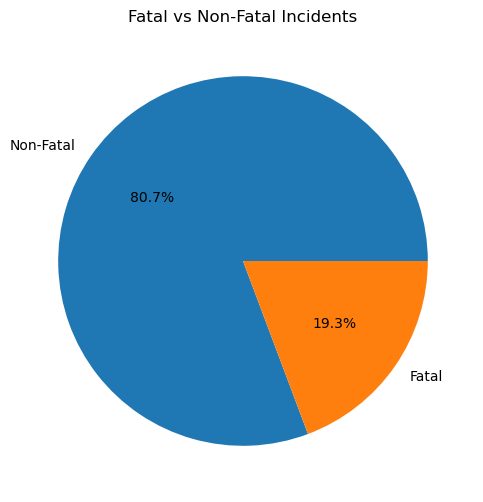

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("NYPD_Shooting_Incident_Data__Historic_.csv")

counts = df['STATISTICAL_MURDER_FLAG'].value_counts()

labels = ['Non-Fatal', 'Fatal']

plt.figure(figsize=(6,6))
plt.pie(counts, labels=labels, autopct='%1.1f%%')
plt.title('Fatal vs Non-Fatal Incidents')
plt.show()

##### Non-fatal shooting incidents occur more frequently than fatal incidents. Approximately 80.7% of the incidents in the dataset were classified as non-fatal, indicating that most victims survived the shooting events.

#

### Which precincts need more policing?

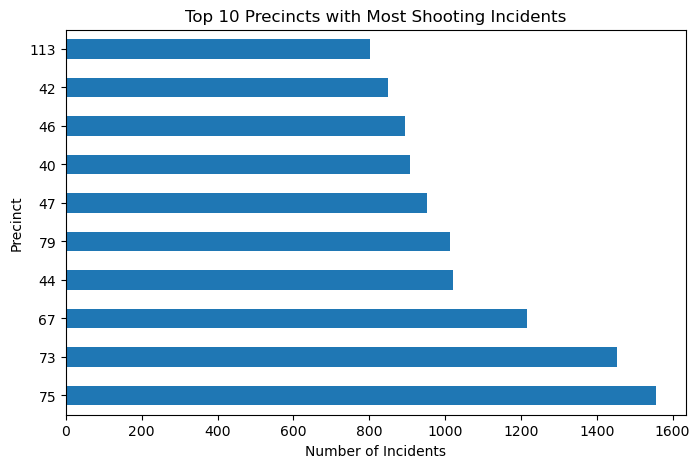

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df['PRECINCT'].value_counts().head(10).plot(kind='barh')

plt.title('Top 10 Precincts with Most Shooting Incidents')
plt.xlabel('Number of Incidents')
plt.ylabel('Precinct')
plt.show()

##### Precinct 75 recorded the highest number of shooting incidents. Law enforcement should prioritize this precinct for increased patrols, surveillance, and crime prevention initiatives.

# 

### Which borough experiences the most shootings?

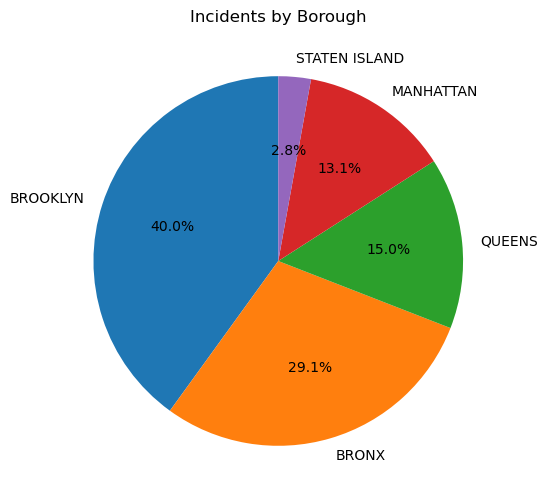

In [5]:
import matplotlib.pyplot as plt

borough = df['BORO'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    borough.values,
    labels=borough.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Incidents by Borough')
plt.show()

##### Brooklyn experienced the highest number of shooting incidents among all boroughs. Additional public safety resources and targeted intervention programs should be focused on this area.

#

### Which age group is most affected?

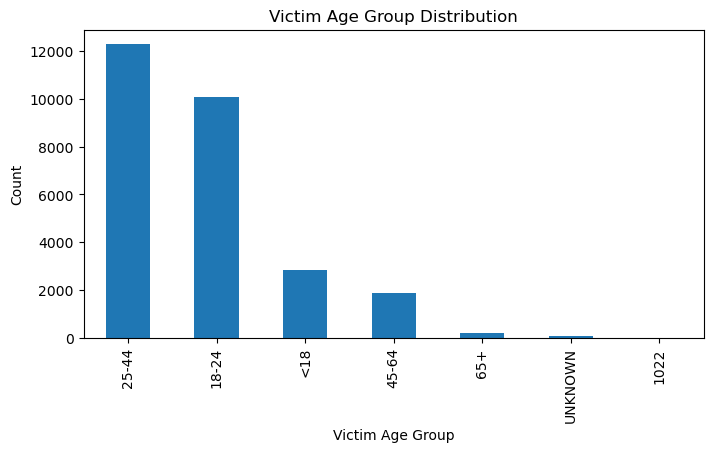

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
df['VIC_AGE_GROUP'].value_counts().plot(kind='bar')

plt.title('Victim Age Group Distribution')
plt.xlabel('Victim Age Group')
plt.ylabel('Count')
plt.show()

##### Individuals aged 25–44 were the most affected victims of shooting incidents. Community awareness and violence prevention programs should target this age group to reduce victimization rates.

#

### Are males or females more affected?

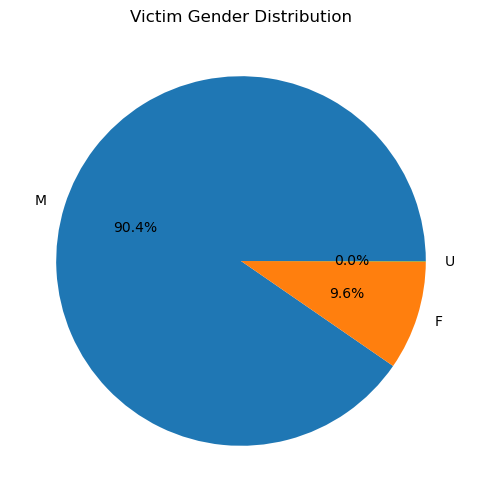

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

df['VIC_SEX'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Victim Gender Distribution')
plt.ylabel('')
plt.show()

##### Male victims represented the majority of shooting incidents. Safety campaigns and risk-reduction strategies should focus primarily on populations most vulnerable to gun violence.

# 

### Which racial groups appear most frequently?

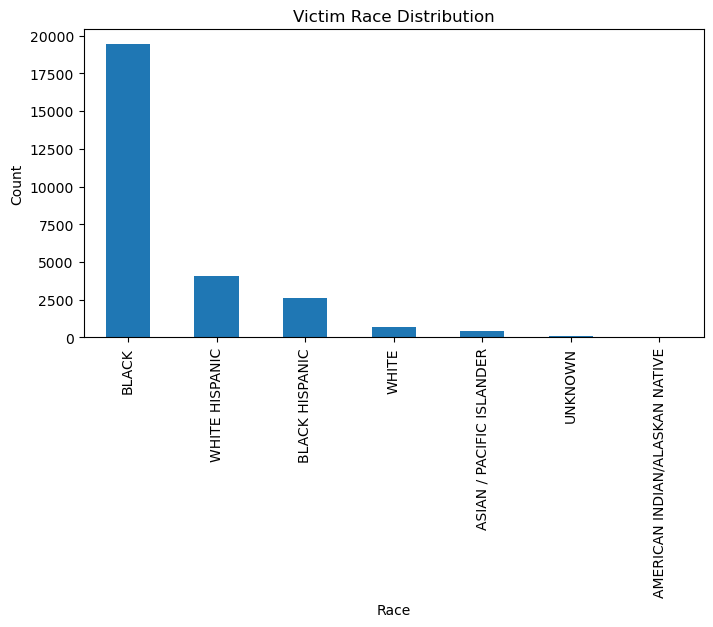

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
df['VIC_RACE'].value_counts().plot(kind='bar')

plt.title('Victim Race Distribution')
plt.xlabel('Race')
plt.ylabel('Count')
plt.show()

##### Black individuals were the most frequently affected victim group in the dataset. Community-based outreach and support programs can help address factors contributing to higher victimization rates.

#

### Which age group commits most incidents?

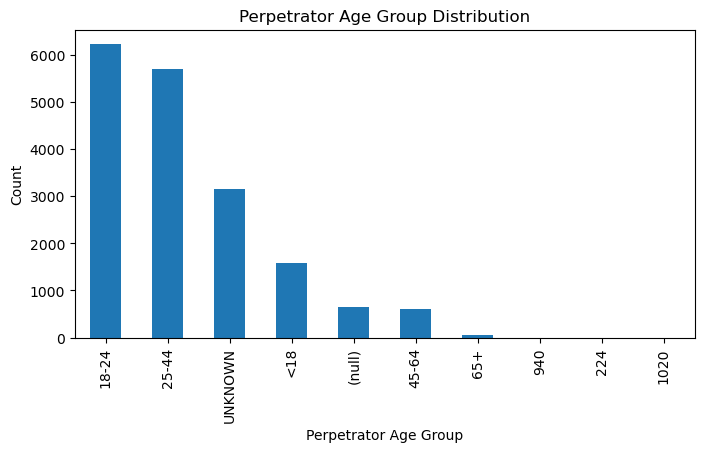

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
df['PERP_AGE_GROUP'].value_counts().plot(kind='bar')

plt.title('Perpetrator Age Group Distribution')
plt.xlabel('Perpetrator Age Group')
plt.ylabel('Count')
plt.show()

##### The 18–24 age group was responsible for the highest number of shooting incidents. Early intervention, education, and employment programs targeting young adults may help reduce crime involvement.

#

### Which Model predicts accurately?

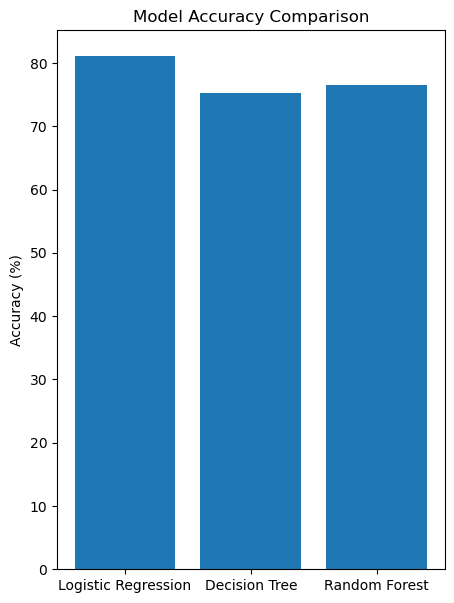

In [10]:
import matplotlib.pyplot as plt
models = ['Logistic Regression',
          'Decision Tree',
          'Random Forest']

accuracy = [81.11,
            75.32,
            76.58]

plt.figure(figsize=(5,7))
plt.bar(models, accuracy)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.show()

##### Logistic Regression achieved the highest accuracy (81.11%), while Random Forest provided more balanced predictions for both fatal and non-fatal incidents. Therefore, Random Forest is more suitable for practical decision-making and operational planning.

#

## Which factors contribute most to fatality prediction?


Feature Importance:
               Feature  Importance
2             PRECINCT    0.404958
5        LOCATION_DESC    0.117891
9        VIC_AGE_GROUP    0.097586
6       PERP_AGE_GROUP    0.092122
11            VIC_RACE    0.090825
8            PERP_RACE    0.054431
0                 BORO    0.045432
10             VIC_SEX    0.030937
7             PERP_SEX    0.022718
3    JURISDICTION_CODE    0.019843
4   LOC_CLASSFCTN_DESC    0.014657
1    LOC_OF_OCCUR_DESC    0.008601


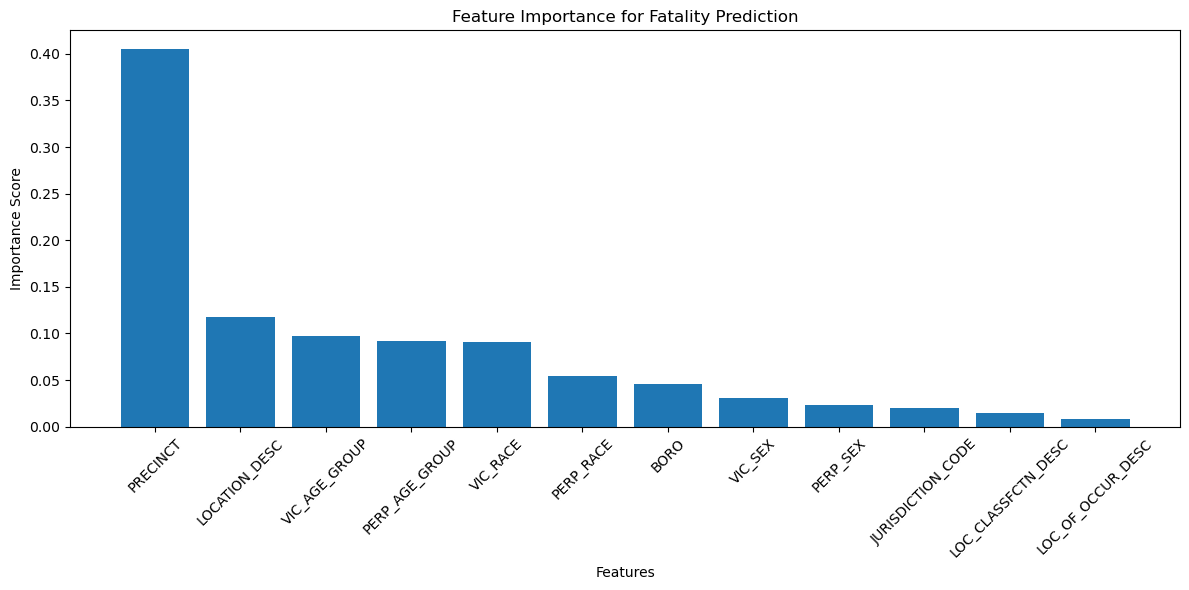

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("NYPD_Shooting_Incident_Data__Historic_.csv")

df = df.drop([
    'INCIDENT_KEY',
    'OCCUR_DATE',
    'OCCUR_TIME',
    'X_COORD_CD',
    'Y_COORD_CD',
    'Latitude',
    'Longitude',
    'Lon_Lat'
], axis=1)

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = df[col].fillna(0)

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

df['STATISTICAL_MURDER_FLAG'] = df['STATISTICAL_MURDER_FLAG'].astype(int)

X = df.drop('STATISTICAL_MURDER_FLAG', axis=1)
y = df['STATISTICAL_MURDER_FLAG']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance)

plt.figure(figsize=(12,6))
plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance for Fatality Prediction")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### PRECINCT was identified as the most influential factor in fatality prediction. This shows that geographic location is a key determinant of risk, enabling law enforcement to focus resources on high-risk areas.

#